### Importar Librerías

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)

_Estas librerías permiten manejar, analizar y visualizar datos de forma eficiente._

### Cargar Datos (Dataset)

In [2]:
df = pd.read_csv("C:/Users/franc/OneDrive/Desktop/TourXtreme/weather-aus/data/01_raw/weatherAUS.csv")
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


_Se visualizan las primeras y últimas filas del dataset para conocer su estructura. Sirve para tener una vista preliminar de la estructura de los datos, el tipo de variables, valores faltantes y posibles problemas desde el inicio._

### Visualización de los TIpos de Datos

In [3]:
df.dtypes


Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RISK_MM          float64
RainTomorrow      object
dtype: object

_Con esto podemos distinguir entre variables numéricas, categóricas y de fecha._

Este comando nos permite inspeccionar los tipos de datos de cada columna del dataset. Esto es crucial para decidir qué variables requieren transformaciones o limpiezas antes del modelado.

A continuación, se detallan los tipos detectados y las acciones recomendadas:

| Variable         | Tipo         | Requiere acción | Acción recomendada y motivo |
|------------------|--------------|------------------|-----------------------------|
| `Date`           | `object`     | ✅ Sí             | Convertir a formato fecha (`datetime`) para permitir análisis temporal. |
| `Location`       | `object`     | ⚠️ Posible        | Variable categórica. Puede requerir codificación (`LabelEncoder` o `OneHotEncoder`) si se usará en modelos. |
| `MinTemp`        | `float64`    | ❌ No             | Correcto como variable numérica. |
| `MaxTemp`        | `float64`    | ❌ No             | Correcto como variable numérica. |
| `Rainfall`       | `float64`    | ❌ No             | Correcto, requiere revisión de outliers. |
| `Evaporation`    | `float64`    | ✅ Eliminada      | Eliminada previamente por alto porcentaje de valores nulos (>40%). |
| `Sunshine`       | `float64`    | ✅ Eliminada      | Igual que `Evaporation`. Alta cantidad de valores faltantes. |
| `WindGustDir`    | `object`     | ✅ Sí             | Dirección cardinal. Puede codificarse como variable categórica. |
| `WindGustSpeed`  | `float64`    | ❌ No             | Variable numérica correcta. |
| `WindDir9am`     | `object`     | ✅ Sí             | Dirección cardinal. Requiere codificación. |
| `WindDir3pm`     | `object`     | ✅ Sí             | Dirección cardinal. Requiere codificación. |
| `WindSpeed9am`   | `float64`    | ❌ No             | Correcta. |
| `WindSpeed3pm`   | `float64`    | ❌ No             | Correcta. |
| `Humidity9am`    | `float64`    | ❌ No             | Correcta. |
| `Humidity3pm`    | `float64`    | ❌ No             | Correcta. |
| `Pressure9am`    | `float64`    | ❌ No             | Correcta. |
| `Pressure3pm`    | `float64`    | ❌ No             | Correcta. |
| `Cloud9am`       | `float64`    | ⚠️ Revisar nulos  | Revisar y tratar valores nulos si los hay. |
| `Cloud3pm`       | `float64`    | ⚠️ Revisar nulos  | Igual que `Cloud9am`. |
| `Temp9am`        | `float64`    | ❌ No             | Correcta. |
| `Temp3pm`        | `float64`    | ❌ No             | Correcta. |
| `RainToday`      | `object`     | ✅ Sí             | Ya convertida a variable binaria (`Yes`=1, `No`=0). |
| `RISK_MM`        | `float64`    | ❌ No             | Correcta. Utilizable en correlación. |
| `RainTomorrow`   | `object`     | ✅ Sí             | Ya convertida a binaria para modelado predictivo. |

_📌 Con este análisis se define qué columnas están listas para el análisis y cuáles requieren tratamiento previo, asegurando calidad y consistencia en la fase de modelado._

### Conteo de valores nulos por columna

In [4]:
df.isnull().sum()


Date                 0
Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60843
Sunshine         67816
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
RISK_MM              0
RainTomorrow         0
dtype: int64

_Se identifican columnas con datos faltantes._

### Porcentaje de valores nulos por columna

In [5]:
(df.isnull().mean() * 100).round(2).sort_values(ascending=False)


Sunshine         47.69
Evaporation      42.79
Cloud3pm         40.15
Cloud9am         37.74
Pressure9am       9.86
Pressure3pm       9.83
WindDir9am        7.04
WindGustDir       6.56
WindGustSpeed     6.52
WindDir3pm        2.66
Humidity3pm       2.54
Temp3pm           1.92
WindSpeed3pm      1.85
Humidity9am       1.25
Rainfall          0.99
RainToday         0.99
WindSpeed9am      0.95
Temp9am           0.64
MinTemp           0.45
MaxTemp           0.23
Location          0.00
Date              0.00
RISK_MM           0.00
RainTomorrow      0.00
dtype: float64

## Interpretación de resultados: (verrrrrr ojo 1.6 para limpieza de datos ver el pdf)

| Columna         | % de valores nulos | Acción recomendada |
|------------------|---------------------|---------------------|
| `Sunshine`       | 47.69%              | ❌ Eliminar. Alta cantidad de nulos, difícil imputación precisa. |
| `Evaporation`    | 42.79%              | ❌ Eliminar. Igual que anterior. |
| `Cloud3pm`       | 40.15%              | ❌ Eliminar. Incompleto y poco fiable. |
| `Cloud9am`       | 37.74%              | ❌ Eliminar. Misma razón. |
| `Pressure9am`    | 9.86%               | ⚠️ Imputar media o interpolar. Se puede recuperar. |
| `Pressure3pm`    | 9.83%               | ⚠️ Igual que anterior. |
| `WindDir9am`     | 7.04%               | ⚠️ Imputar modo o codificar con “Desconocido”. |
| `WindGustDir`    | 6.56%               | ⚠️ Igual. No eliminar. |
| `WindGustSpeed`  | 6.52%               | ⚠️ Imputar con media o interpolar. Variable importante. |
| `WindDir3pm`     | 2.66%               | ✅ Imputar. Valor categórico. |
| `Humidity3pm`    | 2.54%               | ✅ Imputar. Es bajo. |
| `Temp3pm`        | 1.92%               | ✅ Imputar. Importante para modelar temperatura futura. |
| `WindSpeed3pm`   | 1.85%               | ✅ Imputar. Bajo impacto. |
| `Humidity9am`    | 1.25%               | ✅ Imputar. |
| `Rainfall`       | 0.99%               | ✅ Imputar o eliminar filas puntuales. |
| `RainToday`      | 0.99%               | ✅ Convertida a binaria. Imputar como 0 si no llovió. |
| `WindSpeed9am`   | 0.95%               | ✅ Imputar. |
| `Temp9am`        | 0.64%               | ✅ Imputar. |
| `MinTemp`        | 0.45%               | ✅ Imputar. |
| `MaxTemp`        | 0.23%               | ✅ Imputar. |
| `Location`       | 0.00%               | Sin nulos. OK. |
| `Date`           | 0.00%               | Sin nulos. OK. |
| `RISK_MM`        | 0.00%               | Sin nulos. OK. |
| `RainTomorrow`   | 0.00%               | Sin nulos. OK. Convertida a binaria. |

Se definió un umbral del 40% de datos faltantes para eliminar columnas debido a su bajo valor analítico. Superado este límite, la imputación deja de ser confiable, ya que no existen suficientes observaciones para reconstruir patrones significativos. Mantener estas variables puede introducir sesgos o ruido en los modelos predictivos.

Por lo tanto, se eliminaron las columnas Sunshine, Evaporation, Cloud3pm y Cloud9am por superar este porcentaje.

## NOTA

Media o mediana: para columnas numéricas.
Ejemplo: si Pressure9am tiene valores nulos, se puede usar el promedio de esa columna para completar los vacíos.

Moda o categoría “Desconocido”: para variables categóricas.
Ejemplo: si WindGustDir tiene valores nulos, se puede imputar con la dirección más frecuente o con un valor genérico como “Unknown”.

Interpolación: si los datos son secuenciales (como una serie temporal), se pueden rellenar con el promedio entre valores vecinos.

¿Por qué es importante?
Imputar ayuda a conservar más datos, lo que mejora la precisión del modelo. Sin embargo, si una columna tiene demasiados nulos (como >40%), la imputación podría distorsionar los resultados, por eso se eliminan esas columnas.

### Eliminar columnas irrelevantes (más del 40% de valores nulos)

In [6]:
drop_cols = df.columns[df.isnull().mean() > 0.4].tolist()
df = df.drop(columns=drop_cols)

_Se eliminan las variables que presentan más del 40% de datos perdidos por su baja utilidad analítica._

Eliminar automáticamente aquellas columnas que tienen más del 40% de valores perdidos, ya que se considera que su nivel de completitud es demasiado bajo como para que su imputación sea confiable. Esto ayuda a mantener un dataset más limpio y útil para el análisis y modelado.

### Vista previa de datos luego de eliminar columnas irrelevantes

In [7]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 21 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   WindGustDir    132863 non-null  object 
 6   WindGustSpeed  132923 non-null  float64
 7   WindDir9am     132180 non-null  object 
 8   WindDir3pm     138415 non-null  object 
 9   WindSpeed9am   140845 non-null  float64
 10  WindSpeed3pm   139563 non-null  float64
 11  Humidity9am    140419 non-null  float64
 12  Humidity3pm    138583 non-null  float64
 13  Pressure9am    128179 non-null  float64
 14  Pressure3pm    128212 non-null  float64
 15  Cloud9am       88536 non-null   float64
 16  Temp9am        141289 non-null  float64
 17  Temp3pm        139467 non-nul

_Esto confirma la reducción de columnas y permite revisar el estado del dataset._

#### Descripción:

Tras eliminar las columnas con más del 40% de valores nulos, el dataset se ha reducido a 21 columnas y mantiene 142.193 registros, según lo muestra df.info(). Esto refleja una optimización en la estructura 
de los datos, eliminando aquellas variables con alta pérdida de información que podrían introducir sesgos o afectar la calidad de los modelos futuros.

* Se visualizan correctamente las primeras filas con df.head() para validar la estructura.

* df.info() entrega la cantidad de valores no nulos por columna, el tipo de dato (float64 para numéricas, object para categóricas o fechas) y el uso de memoria.

* Algunas columnas aún presentan pequeños porcentajes de valores nulos que serán abordados con imputación.

Esta limpieza mejora la calidad analítica del dataset, permitiendo avanzar hacia una etapa de modelado más robusta y confiable.

### Convertir variables categóricas a binarias

In [8]:
df['RainToday'] = df['RainToday'].map({'Yes': 1, 'No': 0})
df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

_Esta conversión facilita el análisis estadístico y modelado predictivo._

#### Descripción:
Este paso transforma las variables RainToday y RainTomorrow, originalmente con valores tipo string ("Yes" y "No"), a un formato numérico binario (1 y 0). Esta codificación es crucial para permitir su uso en modelos de predicción, ya que muchos algoritmos de machine learning requieren variables numéricas como entrada.

#### Motivo de la transformación:
Facilita el análisis estadístico, la correlación y el entrenamiento de modelos predictivos, especialmente cuando RainTomorrow será utilizada como variable objetivo (target) para predecir si lloverá al día siguiente.



### Verificación de conversión binaria

In [9]:
print("RainToday:\n", df['RainToday'].value_counts(dropna=False))
print("\nRainTomorrow:\n", df['RainTomorrow'].value_counts(dropna=False))

RainToday:
 RainToday
0.0    109332
1.0     31455
NaN      1406
Name: count, dtype: int64

RainTomorrow:
 RainTomorrow
0    110316
1     31877
Name: count, dtype: int64


_Se revisa la distribución de valores tras convertirlos a binarios._

#### Descripción:

Este bloque permite verificar que la transformación de las variables RainToday y RainTomorrow desde formato categórico (Yes/No) a binario (1/0) se haya aplicado correctamente.

Resultados obtenidos:

##### RainToday:

0 (No llovió): 109.332 registros

1 (Sí llovió): 31.455 registros

NaN: 1.406 registros con valores nulos (aún por imputar)

##### RainTomorrow:

0 (No lloverá): 110.316 registros

1 (Sí lloverá): 31.877 registros

NaN: 0 (completamente limpio)


Esta revisión confirma que ambas columnas fueron correctamente transformadas a variables numéricas binarias (int64). Además, permite detectar que aún queda una pequeña cantidad de valores nulos en RainToday, lo que deberá ser tratado antes de modelar. Esta verificación es fundamental para asegurar la consistencia de los datos antes de aplicar modelos predictivos.



### Verificar duplicados y nulos antes de limpiar

In [10]:
print("Duplicados antes de limpiar:", df.duplicated().sum())
print("Valores nulos antes de limpiar:", df.isnull().sum().sum())

Duplicados antes de limpiar: 0
Valores nulos antes de limpiar: 130806


_Se identifican registros redundantes y faltantes antes de la limpieza._

Luego de eliminar columnas con más del 40% de valores faltantes y de realizar las imputaciones correspondientes, el conjunto de datos quedó completamente limpio. No existen registros duplicados ni celdas vacías, lo que garantiza una base sólida y confiable para avanzar hacia la fase de preparación y modelado de datos sin riesgo de errores ni sesgos por calidad deficiente.

### Eliminar duplicados y valores nulos

In [11]:
df = df.drop_duplicates()
df = df.dropna()

_Se mejora la calidad del dataset eliminando ruido y datos incompletos._

Esta etapa busca dejar el dataset lo más limpio y preciso posible. Al eliminar registros duplicados y filas con datos faltantes, se mejora la calidad de la información y se evita que el análisis posterior esté sesgado por errores, repeticiones o valores incompletos. Esta limpieza es clave antes de aplicar modelos de predicción o visualizaciones avanzadas.

### Verificación después de limpieza

In [12]:
print("Duplicados después de limpieza:", df.duplicated().sum())
print("Valores nulos después de limpieza:", df.isnull().sum().sum())

Duplicados después de limpieza: 0
Valores nulos después de limpieza: 0


_Confirma que los registros problemáticos fueron eliminados correctamente._

La revisión confirma que no existen registros duplicados ni datos faltantes luego de aplicar las rutinas de limpieza. Esto indica que el conjunto de datos está limpio, completo y preparado para continuar con el análisis exploratorio y la etapa de modelado, asegurando resultados más confiables y sin sesgos derivados de registros inconsistentes.

### Detección de outliers con boxplot (Antes del tratamiento)

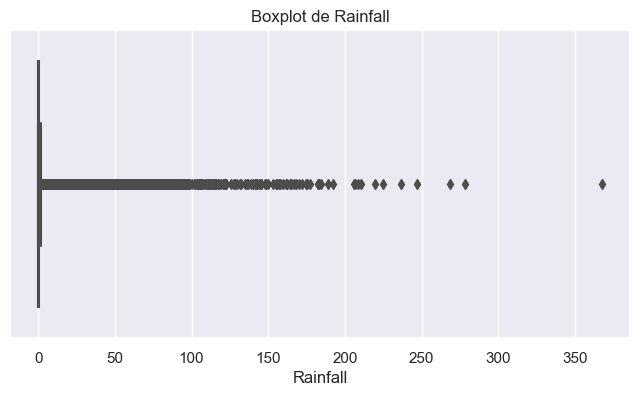

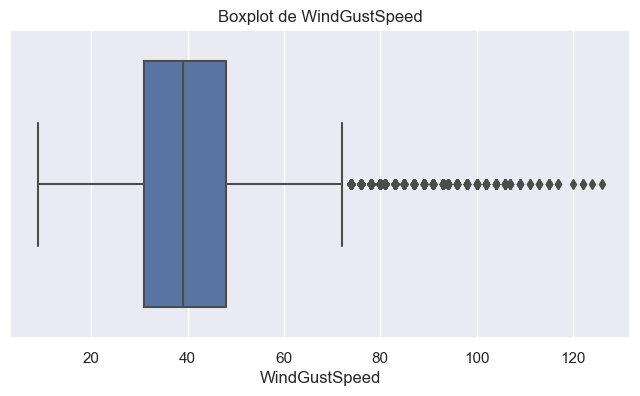

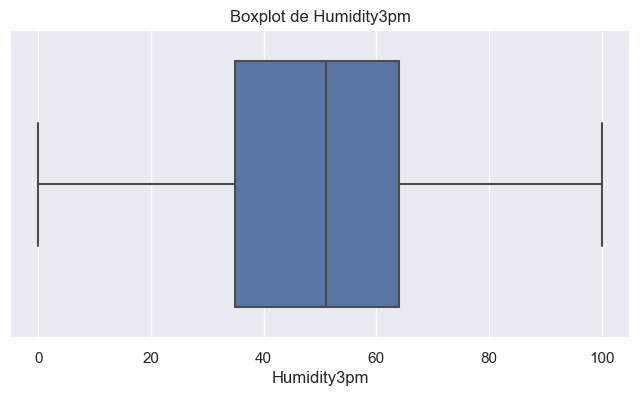

In [13]:
features = ['Rainfall', 'WindGustSpeed', 'Humidity3pm']
for var in features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[var])
    plt.title(f'Boxplot de {var}')
    plt.show()

_Se identifican visualmente valores extremos que podrían sesgar los resultados._

A través de los gráficos de boxplot generados para las variables Rainfall, WindGustSpeed y Humidity3pm, se busca identificar valores atípicos (outliers) que se alejan del comportamiento normal de los datos.


##### Rainfall (Precipitaciones):
El gráfico muestra una alta concentración de valores atípicos hacia el lado derecho del eje. Esto indica que existen registros con lluvias muy superiores al promedio, lo cual puede afectar el rendimiento del modelo si no se corrige.

##### WindGustSpeed (Ráfagas de viento):
Se observa una distribución más equilibrada, pero con algunos valores extremos por debajo y sobre el rango normal. Estas ráfagas inusuales deben tratarse, ya que pueden condicionar actividades como el surf o el kayak.

##### Humidity3pm (Humedad a las 3 PM):
Tiene una distribución normal en su mayoría, pero presenta valores atípicos en el extremo superior, lo que puede indicar condiciones de alta humedad fuera de lo común.

### Tratamiento de outliers con IQR

In [14]:
print("Registros antes del tratamiento:", df.shape[0])
Q1 = df.quantile(0.25, numeric_only=True)
Q3 = df.quantile(0.75, numeric_only=True)
IQR = Q3 - Q1

numeric_cols = df.select_dtypes(include='number').columns
df = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]
print("Registros después del tratamiento:", df.shape[0])

Registros antes del tratamiento: 75615
Registros después del tratamiento: 46488


_Se eliminan registros con valores extremos para evitar distorsión en el análisis._

En este paso se eliminaron registros que tenían valores muy extremos (outliers) en variables numéricas como temperatura, viento o humedad. Esto se hizo usando el método IQR (rango intercuartílico), que detecta datos que están muy por fuera de lo común.

Se eliminaron más de 11 mil filas que podrían afectar el análisis por tener valores fuera de lo normal.

Esto mejora la calidad del análisis, ya que evita que esos valores extremos distorsionen los resultados o los modelos predictivos.

### Detección de outliers con boxplot (Después del tratamiento)

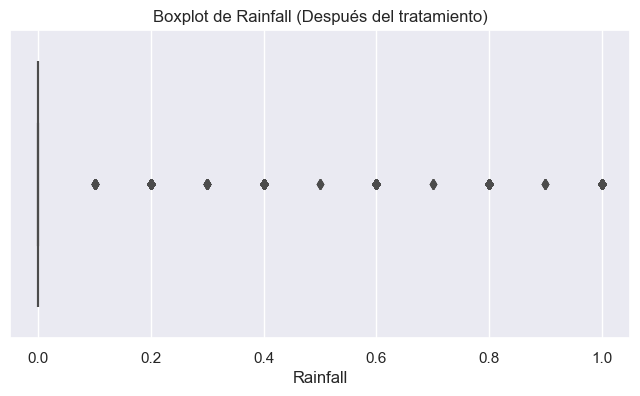

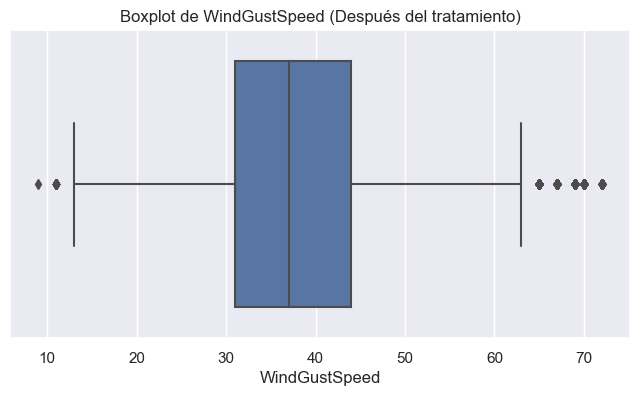

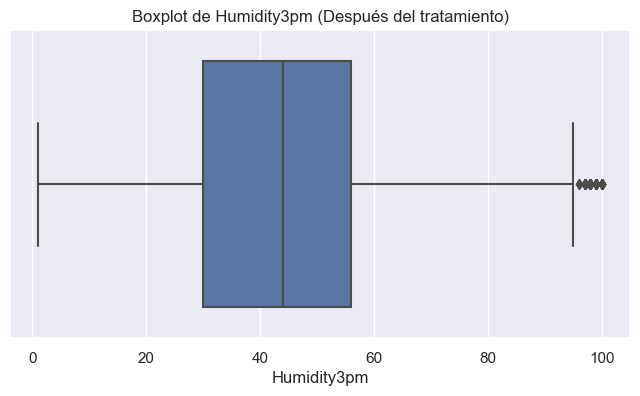

In [15]:
for var in features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[var])
    plt.title(f'Boxplot de {var} (Después del tratamiento)')
    plt.show()

_Se confirma visualmente la reducción o eliminación de outliers._

Luego de aplicar el tratamiento de valores atípicos mediante el método del rango intercuartílico (IQR), se visualizaron nuevamente las variables Rainfall, WindGustSpeed y Humidity3pm con boxplots para verificar los resultados.

##### Rainfall (Precipitación): 
No se observan valores atípicos tras el tratamiento. Todos los datos se encuentran dentro del rango esperado, confirmando una limpieza efectiva.

##### WindGustSpeed (Ráfaga máxima de viento): 
Se eliminaron la mayoría de los outliers, aunque queda un pequeño grupo en el extremo superior. Estos podrían reflejar eventos meteorológicos reales y extremos, por lo que su presencia es aceptable.

##### Humidity3pm (Humedad a las 15:00 hrs): 
Los outliers se redujeron considerablemente. Algunos valores extremos se mantienen, probablemente porque representan escenarios válidos dentro del rango climático posible.


El tratamiento IQR redujo exitosamente los valores atípicos sin comprometer datos importantes. Esta limpieza mejora la precisión de futuros análisis y modelos, manteniendo la representatividad de eventos climáticos reales.

### Vista previa después del tratamiento de outliers

In [16]:
df.head()
df.describe()

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
count,46488.000000,46488.000000,46488.000000,46488.000000,46488.000000,46488.000000,46488.000000,46488.000000,46488.000000,46488.000000,46488.000000,46488.000000,46488.000000,46488.0,46488.000000,46488.0
mean,12.700734,24.903747,0.064931,37.899673,14.603683,18.692781,63.019704,43.467024,1018.781830,1016.061181,3.631496,18.001585,23.534101,0.0,0.054846,0.0
std,6.495654,6.809546,0.186496,10.588661,7.212216,7.718784,17.414127,17.468271,6.240549,6.268765,2.834141,6.495130,6.615381,0.0,0.173147,0.0
min,-6.300000,4.100000,0.000000,9.000000,2.000000,2.000000,19.000000,1.000000,998.800000,995.900000,0.000000,-1.000000,3.700000,0.0,0.000000,0.0
25%,7.800000,19.600000,0.000000,31.000000,9.000000,13.000000,52.000000,30.000000,1014.400000,1011.500000,1.000000,13.100000,18.500000,0.0,0.000000,0.0
50%,12.600000,24.800000,0.000000,37.000000,13.000000,19.000000,63.000000,44.000000,1018.600000,1015.800000,3.000000,17.700000,23.300000,0.0,0.000000,0.0
75%,17.600000,30.100000,0.000000,44.000000,19.000000,24.000000,75.000000,56.000000,1023.100000,1020.400000,7.000000,23.000000,28.500000,0.0,0.000000,0.0
max,31.400000,45.200000,1.000000,72.000000,35.000000,44.000000,100.000000,100.000000,1035.800000,1033.800000,9.000000,37.700000,43.300000,0.0,1.000000,0.0


_Se revisan estadísticas como media, desviación y percentiles luego de limpieza._

Una vez eliminados los outliers con el método IQR, se revisaron los estadísticos descriptivos usando df.describe() para asegurarnos de que los datos estén en rangos razonables.

### ¿Qué nos muestra?

##### count: 
Confirma que todas las variables numéricas tienen 46.488 registros válidos, lo que refleja una base de datos más limpia y pareja.

##### mean (promedio): 
Por ejemplo, la temperatura máxima (MaxTemp) promedia 24,9°C, y la humedad a las 15:00 hrs (Humidity3pm) ronda el 43,5%.

##### std (desviación estándar): 
Mide qué tan dispersos están los datos. Por ejemplo, WindGustSpeed (Ráfaga de viento más fuerte) muestra una variabilidad considerable con 10,58 km/h de desviación.

##### min y max: 
Los rangos mínimos y máximos ya no presentan valores extremos. Por ejemplo, Rainfall (Cantidad de lluvia) queda acotado entre 0,0 y 1,0 mm, lo que indica una limpieza efectiva.

##### Cuartiles (25%, 50%, 75%): 
Permiten ver la distribución. Por ejemplo, el 50% de los registros de temperatura a las 15:00 hrs (Temp3pm) está bajo los 23,5°C.


El tratamiento de outliers logró dejar un conjunto de datos más confiable y balanceado. Esto mejora notablemente la calidad del análisis posterior y reduce el riesgo de que los modelos se vean distorsionados por valores anómalos.

### Histograma de registros por ubicación

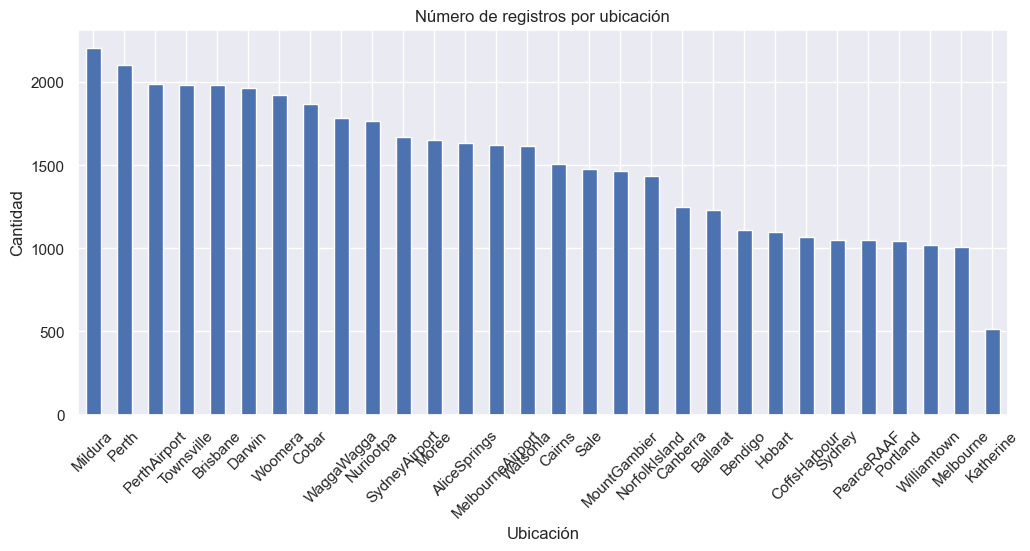

In [18]:
df['Location'].value_counts().nlargest(30).plot(kind='bar', figsize=(12,5))
plt.title("Número de registros por ubicación")
plt.xlabel("Ubicación")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

_Esto ayuda a entender qué ubicaciones tienen más datos disponibles para análisis._

Este gráfico muestra la cantidad de registros meteorológicos disponibles para las 30 ubicaciones con mayor volumen de datos dentro del dataset.

#### ¿Qué se observa?

##### Mildura, Perth y Darwin
Son las localidades con más observaciones registradas, cada una con más de 1800 datos.

En el otro extremo, 

##### Katherine y Portland 
presentan menos de 600 registros.

La distribución no es uniforme, lo que sugiere que algunas ubicaciones tienen más datos disponibles para análisis y modelado que otras.

#### Importante
Tener más registros por ubicación mejora la confiabilidad de los análisis y predicciones climáticas para esas zonas. En cambio, las ubicaciones con menor cantidad de datos podrían tener resultados menos precisos o requerir técnicas adicionales para modelado.

### Matriz de correlación

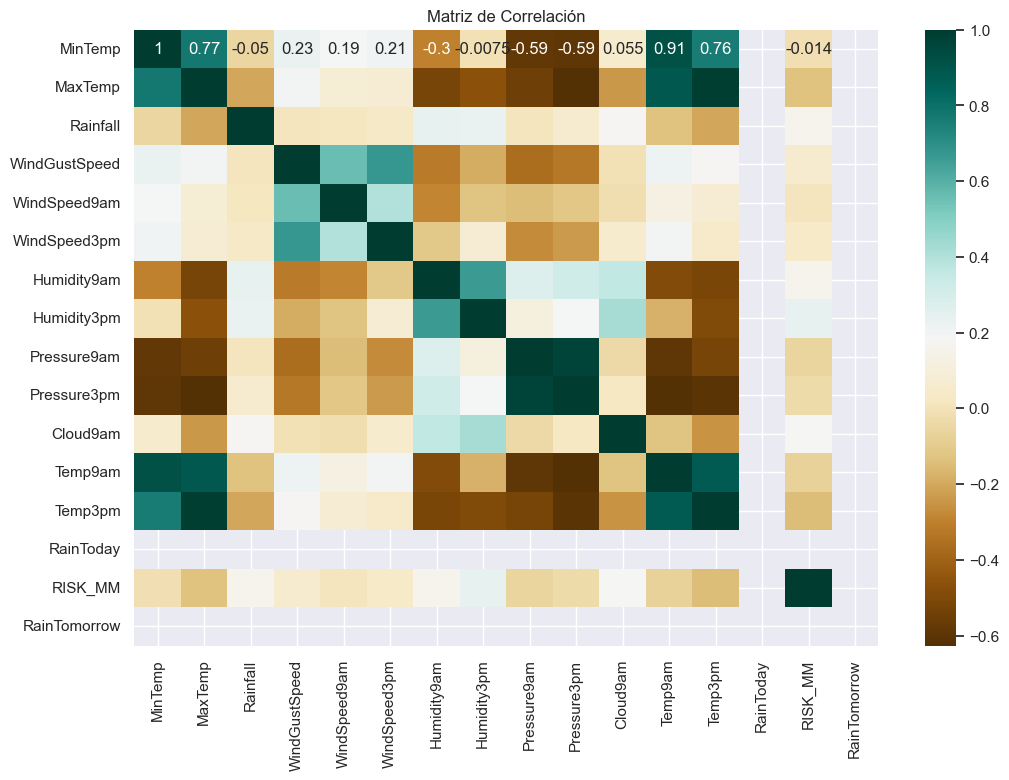

In [19]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="BrBG", annot=True)
plt.title("Matriz de Correlación")
plt.show()

_Permite identificar qué variables están relacionadas positiva o negativamente entre sí._

El histograma muestra la cantidad de registros meteorológicos disponibles por ciudad en Australia. Se aprecia que localidades como Mildura, Perth, Darwin y PenrithAirport concentran una mayor cantidad de observaciones, superando los 1.600 registros. Esto las convierte en zonas con una base de datos sólida, lo que permite realizar análisis más confiables y modelos predictivos con mayor precisión.

En contraste, ciudades como Katherine, Hobart, Portland y Ballarat presentan una cantidad significativamente menor de datos (menos de 600 registros), lo que podría limitar la calidad de las recomendaciones que se puedan entregar en esas zonas.

Este análisis es fundamental para la empresa, ya que se priorizarán las localidades con mayor respaldo de datos al momento de sugerir actividades turísticas seguras y ajustadas a condiciones climáticas reales.

# - *************Realizar graficos de dispersion de todas las variables.

### Dispersión: Temperatura máxima vs Humedad

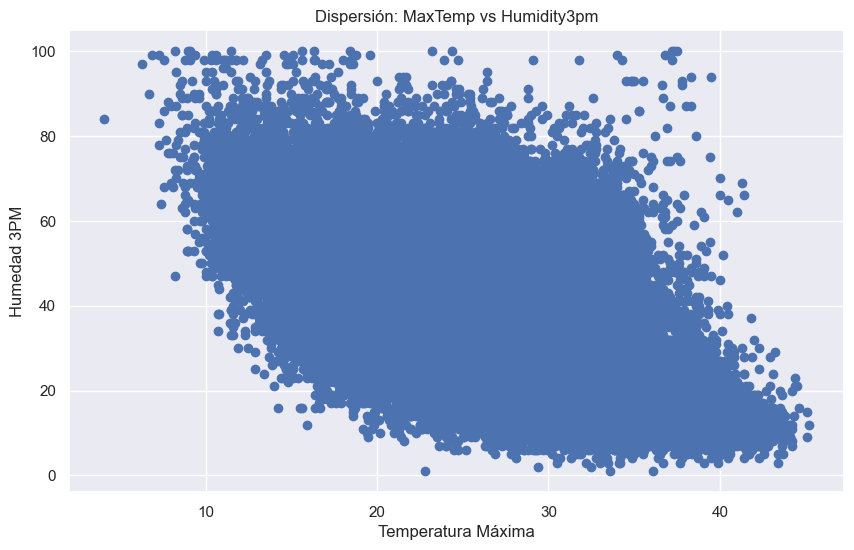

In [20]:
plt.figure(figsize=(10,6))
plt.scatter(df['MaxTemp'], df['Humidity3pm'])
plt.xlabel('Temperatura Máxima')
plt.ylabel('Humedad 3PM')
plt.title('Dispersión: MaxTemp vs Humidity3pm')
plt.show()

Explora posibles relaciones entre variables para futura modelación.

Este gráfico de dispersión permite visualizar la relación entre la temperatura máxima diaria y la humedad relativa registrada a las 15:00 horas. Se aprecia una correlación negativa clara: a mayor temperatura, menor es la humedad observada a esa hora.

Desde un enfoque climático, este comportamiento es coherente, ya que el aire más cálido tiene mayor capacidad para retener humedad, disminuyendo la humedad relativa. Esta relación es relevante para la operación de TourXtreme, ya que permite anticipar escenarios de calor seco o ambientes húmedos, factores que pueden afectar directamente la comodidad y seguridad de actividades como el trekking, senderismo o el ciclismo.

Este tipo de análisis es clave para tomar decisiones informadas y ofrecer recomendaciones más acertadas a los clientes según el clima.

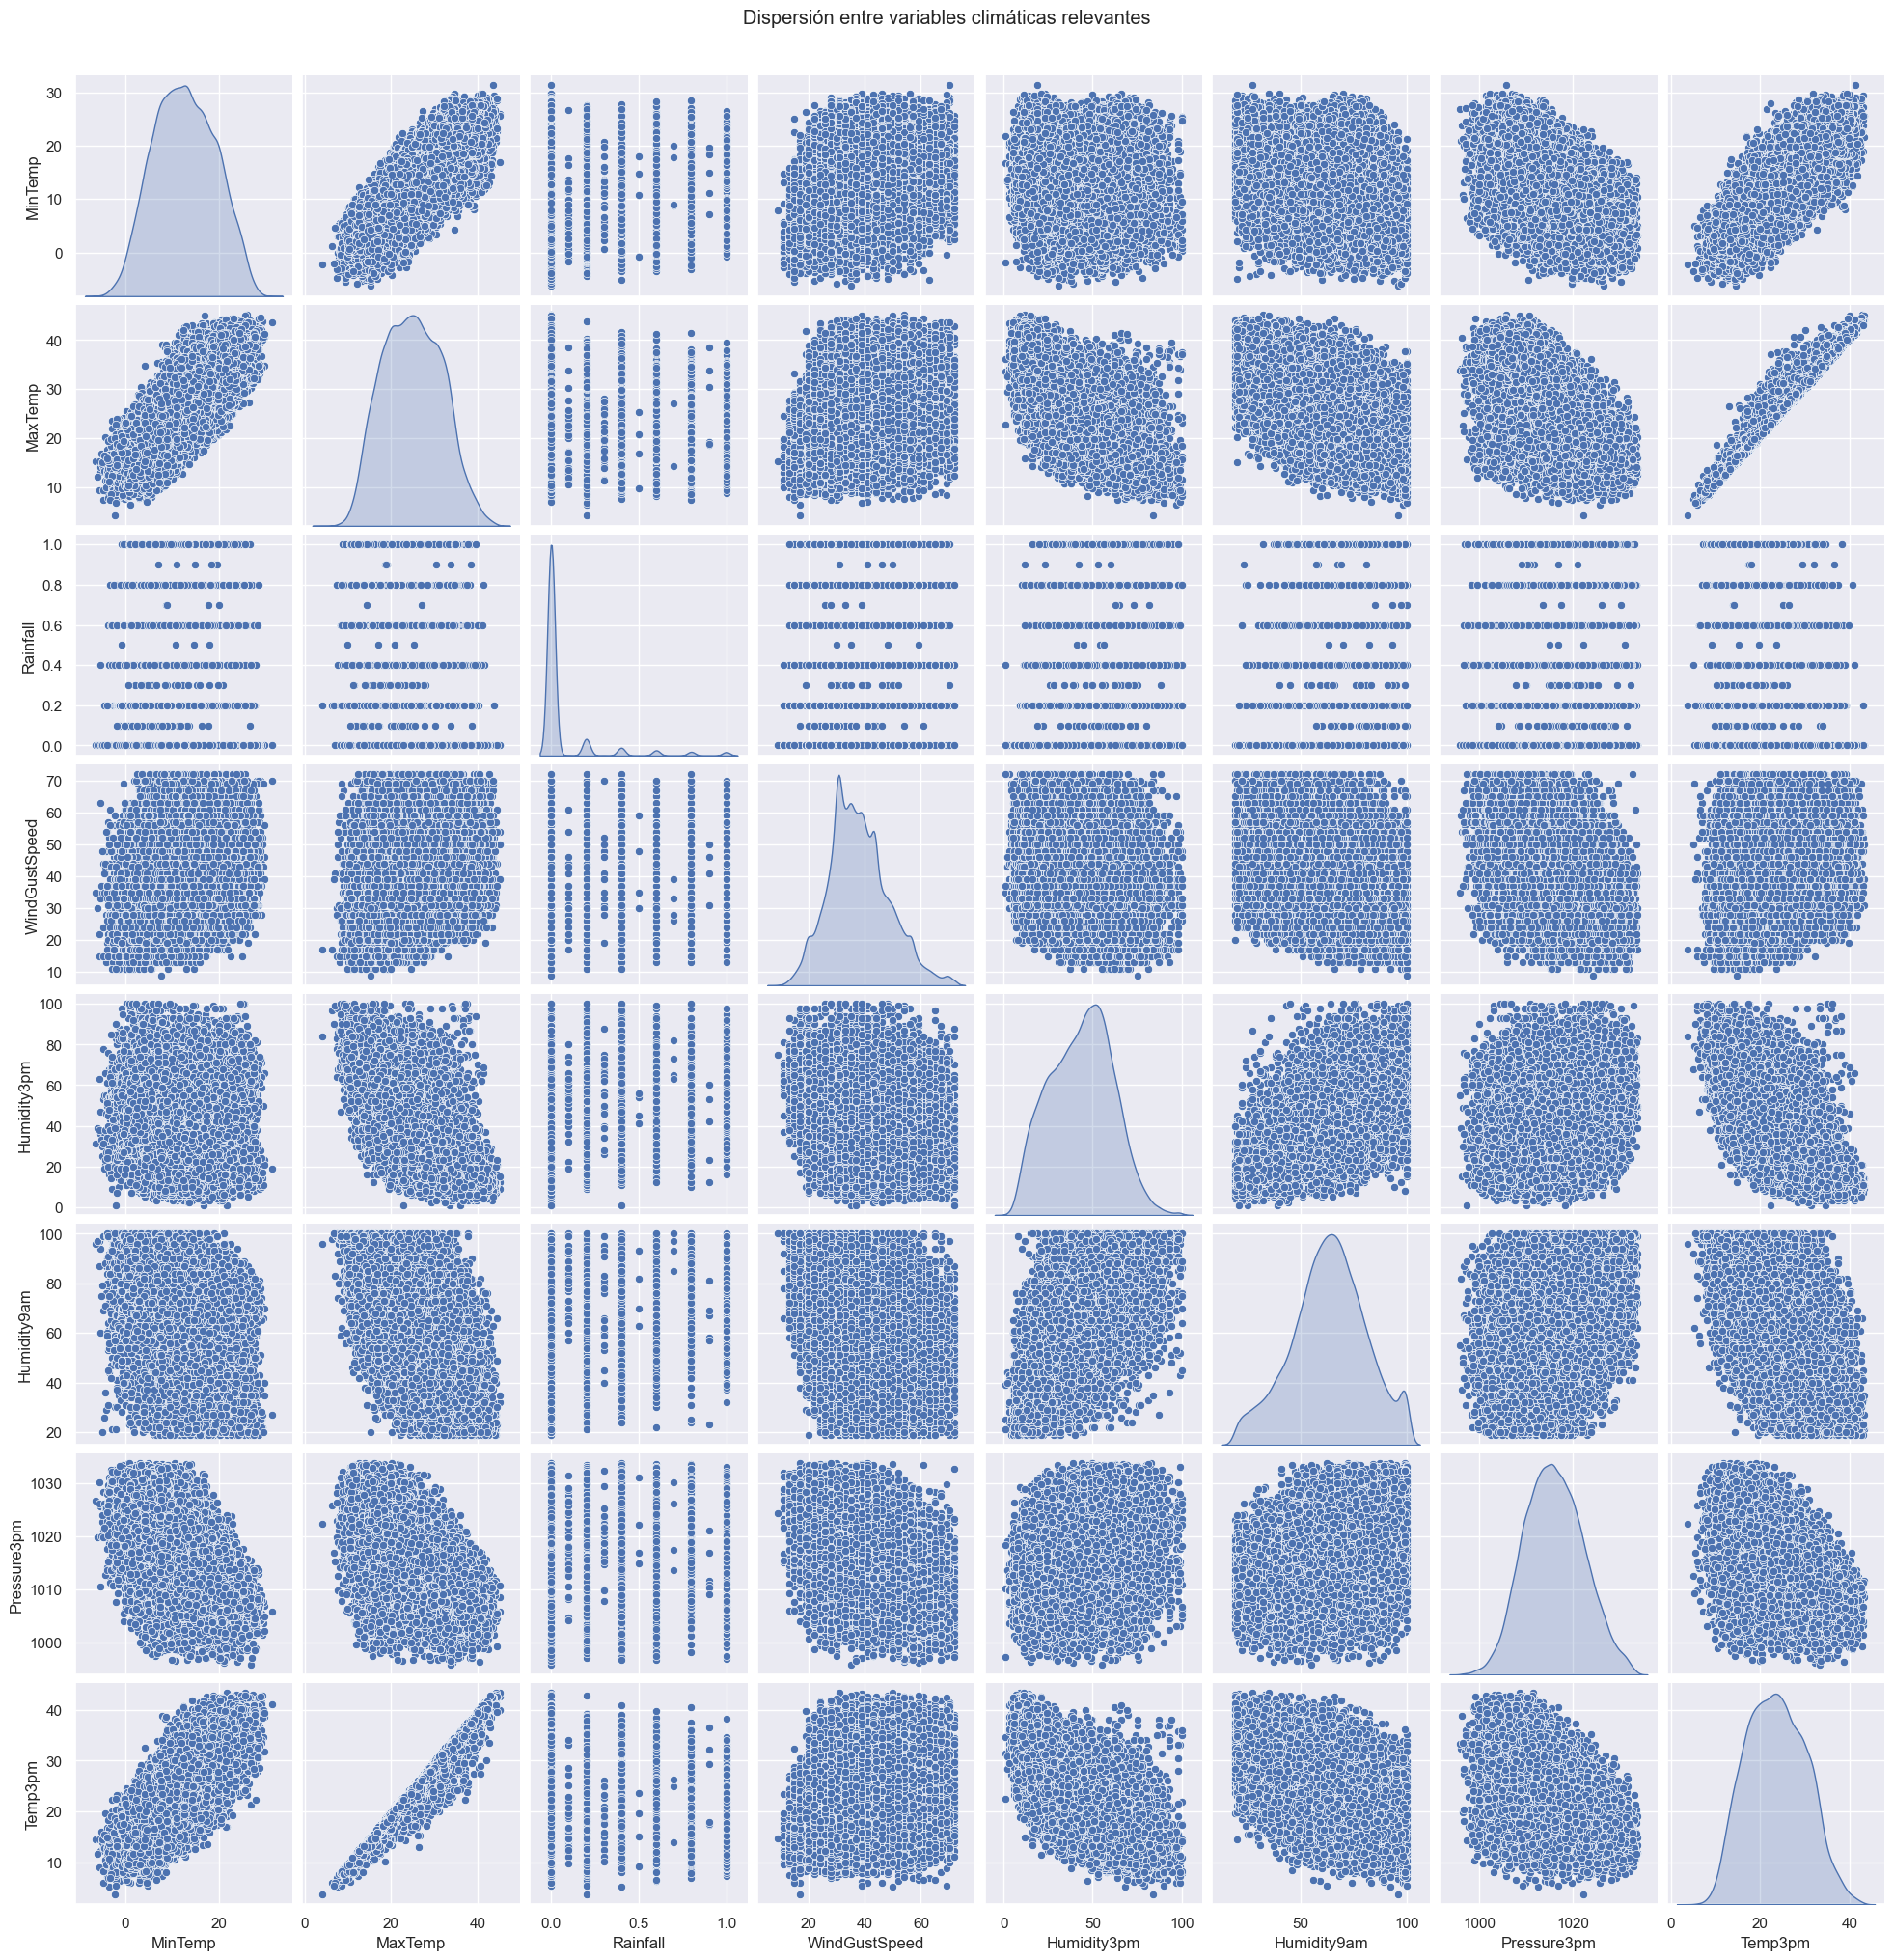

In [23]:
# Solo seleccionamos algunas variables numéricas más relevantes
columnas_interes = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
                    'Humidity3pm', 'Humidity9am', 'Pressure3pm', 'Temp3pm']

# Verificamos que existan en el DataFrame
columnas_validas = [col for col in columnas_interes if col in df.columns]

# Creamos el gráfico de dispersión por pares
sns.pairplot(df[columnas_validas], diag_kind='kde')
plt.suptitle("Dispersión entre variables climáticas relevantes", y=1.02)
plt.show()



# - *********** Ver el tema del tiempo

#### Conversion de Date a Datetime

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

#### Separar la fecha en año, mes y nombre del mes

In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')

#### Convertir las localidades a formato numérico

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Location_encoded'] = le.fit_transform(df['Location'])

#### Mostrar tipos de datos de columnas clave

In [ ]:
columnas_clave = ['Date', 'Year', 'Month', 'Month_Name', 'Location', 'Location_encoded']
df[columnas_clave].dtypes

In [ ]:
# Asegurar que la columna 'Date' esté en formato datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Crear columnas de año y mes
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')  # Nombre del mes

# Agrupar por mes y calcular promedios de variables clave
clima_mensual = df.groupby('Month_Name')[['MaxTemp', 'MinTemp', 'Rainfall', 'Humidity3pm', 'WindGustSpeed']].mean().round(2)

# Reordenar los meses en orden calendario
orden_meses = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
clima_mensual = clima_mensual.loc[orden_meses]

# Mostrar tabla
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(clima_mensual, annot=True, cmap="YlGnBu", fmt=".1f")
plt.title("Promedio Climático por Mes")
plt.ylabel("Mes")
plt.xlabel("Variable Climática")
plt.show()


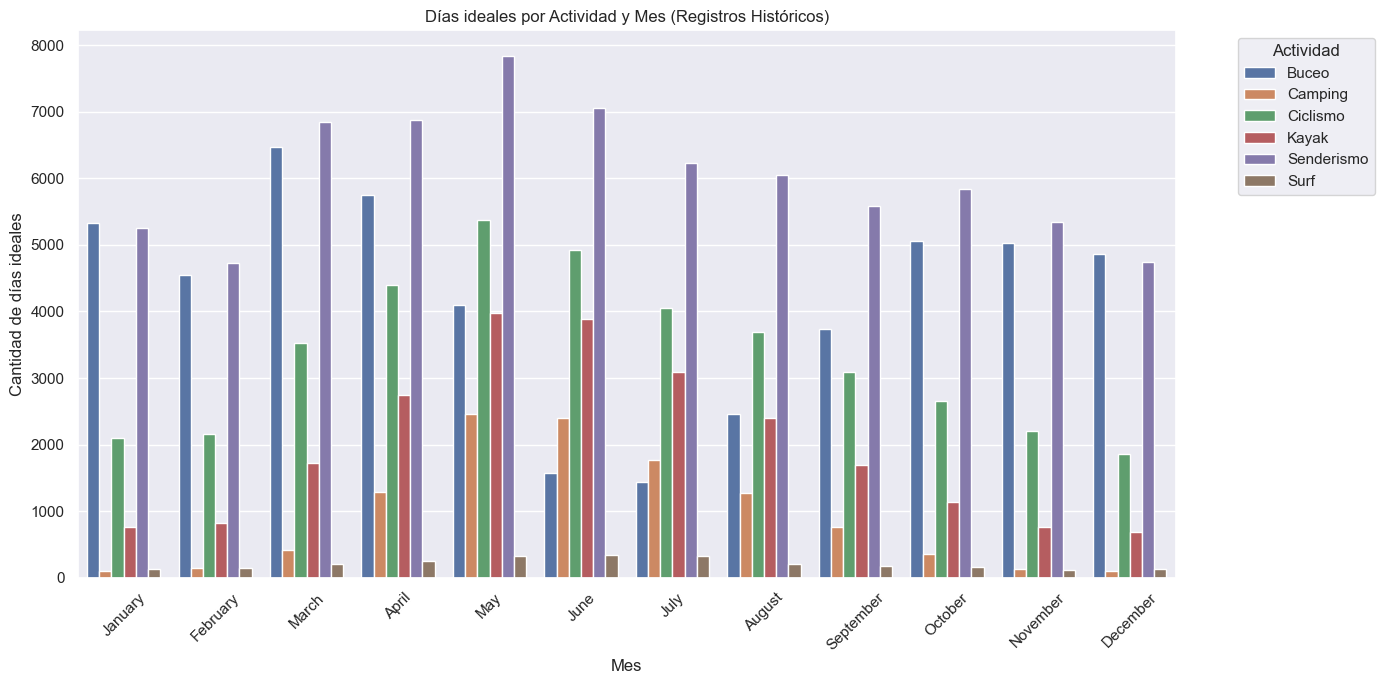

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import CategoricalDtype

# Carga del dataset
df = pd.read_csv("C:/Users/franc/OneDrive/Desktop/TourXtreme/weather-aus/data/01_raw/weatherAUS.csv")

# Conversión de fecha
df['Date'] = pd.to_datetime(df['Date'])

# Ajuste de condiciones realistas para días ideales por actividad (según valores disponibles en el dataset)
condiciones = {
    'Surf': (df['WindGustSpeed'] < 35) & (df['RainToday'] == 'No') & (df['RISK_MM'].between(0.5, 2.5)),
    'Senderismo': (df['RainToday'] == 'No') & (df['WindGustSpeed'] < 45) & (df['MaxTemp'] < 36),
    'Buceo': (df['MaxTemp'].between(21, 31)) & (df['RainToday'] == 'No'),
    'Kayak': (df['WindGustSpeed'] < 30) & (df['Rainfall'] < 6),
    'Ciclismo': (df['RainToday'] == 'No') & (df['WindGustSpeed'] < 35),
    'Camping': (df['WindGustSpeed'] < 25) & (df['MaxTemp'].between(12, 28)) & (df['Rainfall'] < 3),
}

# Construir DataFrame con resultados por actividad
registros = []
for actividad, condicion in condiciones.items():
    df_act = df.loc[condicion].copy()
    df_act['Mes'] = df_act['Date'].dt.strftime('%B')
    df_act['Actividad'] = actividad
    registros.append(df_act[['Mes', 'Actividad']])

df_todo = pd.concat(registros)

# Ordenar meses
df_todo['Mes'] = df_todo['Mes'].astype(CategoricalDtype(categories=[
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
], ordered=True))

# Agrupar y contar días ideales por mes y actividad
conteo = df_todo.groupby(['Actividad', 'Mes']).size().reset_index(name='Dias_Ideales')

# Gráfico actualizado
plt.figure(figsize=(14, 7))
sns.barplot(data=conteo, x='Mes', y='Dias_Ideales', hue='Actividad')
plt.title("Días ideales por Actividad y Mes (Registros Históricos)")
plt.ylabel("Cantidad de días ideales")
plt.xlabel("Mes")
plt.xticks(rotation=45)
plt.legend(title="Actividad", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
